In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('employee_data_eda.csv')

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,YearsOutsideCompany,Overtime_LowSatisfaction
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0,8,0,1,6,4,0,5,2,0
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,1,10,3,3,10,7,1,7,0,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,0,7,3,3,0,0,0,0,7,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,0,8,3,3,8,7,3,0,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,1,6,3,3,2,2,2,2,4,0


In [4]:
print(df.shape)
print(df.columns.tolist())

(1470, 33)
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'YearsOutsideCompany', 'Overtime_LowSatisfaction']


In [5]:
print("Final dataset shape:", df.shape)

Final dataset shape: (1470, 33)


In [6]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [12]:
y = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

X = df.drop(columns="Attrition", axis=1)

In [13]:
# create column transformer for preprocessing 

num_features = X.select_dtypes(exclude="object").columns.tolist()
cat_features = X.select_dtypes(include="object").columns.tolist()

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer


numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()


preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_features),
        ("StandardScaler",numeric_transformer,num_features),
    ]
)

In [14]:
X

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,YearsOutsideCompany,Overtime_LowSatisfaction
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,0,8,0,1,6,4,0,5,2,0
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,...,1,10,3,3,10,7,1,7,0,0
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,...,0,7,3,3,0,0,0,0,7,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,...,0,8,3,3,8,7,3,0,0,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,...,1,6,3,3,2,2,2,2,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,41,...,1,17,3,3,5,2,0,3,12,0
1466,39,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,42,...,1,9,5,3,7,7,1,7,2,0
1467,27,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,87,...,1,6,0,3,6,2,0,3,0,1
1468,49,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,63,...,0,17,3,2,9,6,0,8,8,0


In [15]:
## Getting All Different Types OF Features
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Num of Categorical Features :', len(cat_features))
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Num of Discrete Features :',len(discrete_features))
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuous_features))

Num of Numerical Features : 25
Num of Categorical Features : 8
Num of Discrete Features : 16
Num of Continuous Features : 9


In [19]:
y

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

In [17]:
X

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,YearsOutsideCompany,Overtime_LowSatisfaction
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,0,8,0,1,6,4,0,5,2,0
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,...,1,10,3,3,10,7,1,7,0,0
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,...,0,7,3,3,0,0,0,0,7,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,...,0,8,3,3,8,7,3,0,0,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,...,1,6,3,3,2,2,2,2,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,41,...,1,17,3,3,5,2,0,3,12,0
1466,39,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,42,...,1,9,5,3,7,7,1,7,2,0
1467,27,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,87,...,1,6,0,3,6,2,0,3,0,1
1468,49,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,63,...,0,17,3,2,9,6,0,8,8,0


In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
X_train.shape,X_test.shape

((1176, 32), (294, 32))

In [21]:
X_train = preprocessor.fit_transform(X_train)

In [22]:
X_test = preprocessor.transform(X_test)

In [23]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1176, 53)
X_test shape: (294, 53)


In [24]:
def evaluate_model(true, predicted):

    accuracy = accuracy_score(true, predicted)
    precision = precision_score(true, predicted)
    recall = recall_score(true, predicted)
    f1 = f1_score(true, predicted)

    return accuracy, precision, recall, f1

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}


for name , model in models.items():
    # Train model
    model.fit(X_train,y_train)

    #Predictions

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate training test

    train_accuracy, train_precision , train_recall, train_f1 = evaluate_model(
        y_train,
        y_train_pred
    )


  
    # Evaluate test set
    test_accuracy,test_precision,test_recall,test_f1 = evaluate_model(
        y_test,
        y_test_pred
    )

    print(name)

    print("Training Performance")
    print("- Accuracy :", train_accuracy)
    print("- Precision:", train_precision)
    print("- Recall   :", train_recall)
    print("- F1 Score :", train_f1)

    print("\nTest Performance")
    print("- Accuracy :", test_accuracy)
    print("- Precision:", test_precision)
    print("- Recall   :", test_recall)
    print("- F1 Score :", test_f1)

    print("=" * 50)

    

Logistic Regression
Training Performance
- Accuracy : 0.9047619047619048
- Precision: 0.8421052631578947
- Recall   : 0.5052631578947369
- F1 Score : 0.631578947368421

Test Performance
- Accuracy : 0.8605442176870748
- Precision: 0.6153846153846154
- Recall   : 0.3404255319148936
- F1 Score : 0.4383561643835616
Decision Tree
Training Performance
- Accuracy : 1.0
- Precision: 1.0
- Recall   : 1.0
- F1 Score : 1.0

Test Performance
- Accuracy : 0.7755102040816326
- Precision: 0.30612244897959184
- Recall   : 0.3191489361702128
- F1 Score : 0.3125
Random Forest
Training Performance
- Accuracy : 1.0
- Precision: 1.0
- Recall   : 1.0
- F1 Score : 1.0

Test Performance
- Accuracy : 0.8469387755102041
- Precision: 0.6
- Recall   : 0.1276595744680851
- F1 Score : 0.21052631578947367
Gradient Boosting
Training Performance
- Accuracy : 0.95578231292517
- Precision: 1.0
- Recall   : 0.7263157894736842
- F1 Score : 0.8414634146341463

Test Performance
- Accuracy : 0.8537414965986394
- Precision: 

In [26]:
print(y_train.value_counts())
print(y_test.value_counts())

Attrition
0    986
1    190
Name: count, dtype: int64
Attrition
0    247
1     47
Name: count, dtype: int64


In [28]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [29]:
logistic_model = models["Logistic Regression"]

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

print(pd.Series(y_pred).value_counts())

0    268
1     26
Name: count, dtype: int64


In [30]:
print(pd.Series(y_pred).value_counts(normalize=True))

0    0.911565
1    0.088435
Name: proportion, dtype: float64


In [31]:
logistic_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

logistic_balanced.fit(X_train, y_train)

y_pred_balanced = logistic_balanced.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_balanced)
precision = precision_score(y_test, y_pred_balanced)
recall = recall_score(y_test, y_pred_balanced)
f1 = f1_score(y_test, y_pred_balanced)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7517006802721088
Precision: 0.3488372093023256
Recall   : 0.6382978723404256
F1 Score : 0.45112781954887216


In [ ]:
print(pd.Series(y_pred_balanced).value_counts())

0    1062
1     938
Name: count, dtype: int64


In [32]:
print(pd.Series(y_pred_balanced).value_counts())
print(pd.Series(y_pred_balanced).value_counts(normalize=True))

0    208
1     86
Name: count, dtype: int64
0    0.707483
1    0.292517
Name: proportion, dtype: float64


In [33]:
cm = confusion_matrix(y_test, y_pred_balanced)

print(cm)

[[191  56]
 [ 17  30]]


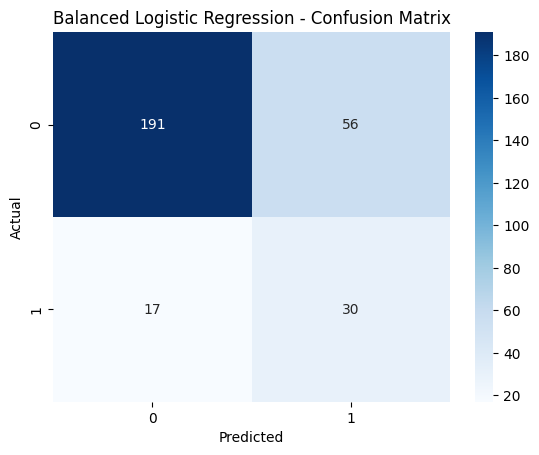

In [34]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Balanced Logistic Regression - Confusion Matrix")

plt.show()

In [38]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier()
}

In [39]:
def evaluate_model(true, predicted):

    accuracy = accuracy_score(true, predicted)
    precision = precision_score(true, predicted)
    recall = recall_score(true, predicted)
    f1 = f1_score(true, predicted)

    return accuracy, precision, recall, f1

In [40]:
for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training performance
    train_accuracy, train_precision, train_recall, train_f1 = evaluate_model(
        y_train,
        y_train_pred
    )

    # Testing performance
    test_accuracy, test_precision, test_recall, test_f1 = evaluate_model(
        y_test,
        y_test_pred
    )

    print(name)

    print("Training Performance")
    print("- Accuracy :", train_accuracy)
    print("- Precision:", train_precision)
    print("- Recall   :", train_recall)
    print("- F1 Score :", train_f1)

    print("\nTest Performance")
    print("- Accuracy :", test_accuracy)
    print("- Precision:", test_precision)
    print("- Recall   :", test_recall)
    print("- F1 Score :", test_f1)

    print("=" * 50)

Logistic Regression
Training Performance
- Accuracy : 0.7814625850340136
- Precision: 0.4092140921409214
- Recall   : 0.7947368421052632
- F1 Score : 0.5402504472271914

Test Performance
- Accuracy : 0.7517006802721088
- Precision: 0.3488372093023256
- Recall   : 0.6382978723404256
- F1 Score : 0.45112781954887216
Decision Tree
Training Performance
- Accuracy : 1.0
- Precision: 1.0
- Recall   : 1.0
- F1 Score : 1.0

Test Performance
- Accuracy : 0.7517006802721088
- Precision: 0.24
- Recall   : 0.2553191489361702
- F1 Score : 0.24742268041237114
Random Forest
Training Performance
- Accuracy : 1.0
- Precision: 1.0
- Recall   : 1.0
- F1 Score : 1.0

Test Performance
- Accuracy : 0.8469387755102041
- Precision: 0.625
- Recall   : 0.10638297872340426
- F1 Score : 0.18181818181818182
Gradient Boosting
Training Performance
- Accuracy : 0.95578231292517
- Precision: 1.0
- Recall   : 0.7263157894736842
- F1 Score : 0.8414634146341463

Test Performance
- Accuracy : 0.8537414965986394
- Precisio

In [42]:
logistic_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

logistic_balanced.fit(X_train, y_train)

y_prob = logistic_balanced.predict_proba(X_test)[:, 1]

print(y_prob[:20])

[0.28345468 0.02278735 0.41710479 0.03809504 0.66264524 0.63394687
 0.07579748 0.15070931 0.02102869 0.23671257 0.2427954  0.47345241
 0.84070065 0.55230625 0.64159843 0.71232991 0.15738048 0.03680966
 0.56032774 0.08224403]


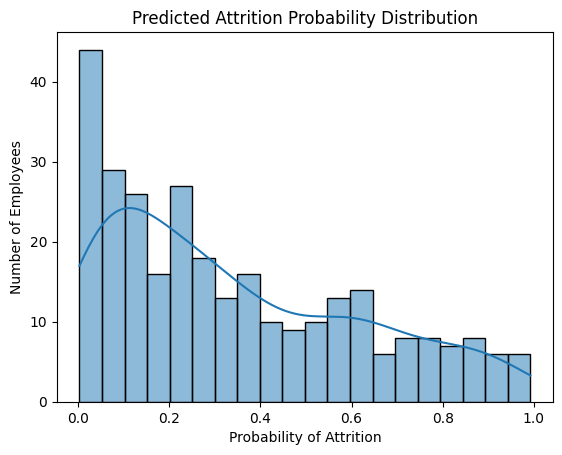

In [43]:
sns.histplot(y_prob, bins=20, kde=True)

plt.xlabel("Probability of Attrition")
plt.ylabel("Number of Employees")
plt.title("Predicted Attrition Probability Distribution")

plt.show()

In [44]:
y_pred_05 = (y_prob >= 0.5).astype(int)

print(pd.Series(y_pred_05).value_counts())

0    208
1     86
Name: count, dtype: int64


In [45]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Threshold:", threshold)
    print("Accuracy :", round(accuracy, 3))
    print("Precision:", round(precision, 3))
    print("Recall   :", round(recall, 3))
    print("F1 Score :", round(f1, 3))
    print("-" * 40)

Threshold: 0.3
Accuracy : 0.643
Precision: 0.284
Recall   : 0.809
F1 Score : 0.42
----------------------------------------
Threshold: 0.35
Accuracy : 0.687
Precision: 0.314
Recall   : 0.809
F1 Score : 0.452
----------------------------------------
Threshold: 0.4
Accuracy : 0.738
Precision: 0.356
Recall   : 0.787
F1 Score : 0.49
----------------------------------------
Threshold: 0.45
Accuracy : 0.731
Precision: 0.33
Recall   : 0.66
F1 Score : 0.44
----------------------------------------
Threshold: 0.5
Accuracy : 0.752
Precision: 0.349
Recall   : 0.638
F1 Score : 0.451
----------------------------------------
Threshold: 0.55
Accuracy : 0.779
Precision: 0.382
Recall   : 0.617
F1 Score : 0.472
----------------------------------------
Threshold: 0.6
Accuracy : 0.806
Precision: 0.419
Recall   : 0.553
F1 Score : 0.477
----------------------------------------


In [46]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8009303126884314


In [47]:
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, rf_prob))

Random Forest ROC-AUC: 0.7785769661469549


In [48]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_prob = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting ROC-AUC:",
      roc_auc_score(y_test, gb_prob))

Gradient Boosting ROC-AUC: 0.8123008011025927


In [49]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

dt_prob = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree ROC-AUC:",
      roc_auc_score(y_test, dt_prob))

Decision Tree ROC-AUC: 0.5507364975450081


In [50]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
importance = rf.feature_importances_

In [52]:
feature_names = preprocessor.get_feature_names_out()

In [55]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
37,StandardScaler__MonthlyIncome,0.064679
44,StandardScaler__TotalWorkingYears,0.056580
28,StandardScaler__Age,0.055609
29,StandardScaler__DailyRate,0.049387
47,StandardScaler__YearsAtCompany,0.043387
33,StandardScaler__HourlyRate,0.041328
30,StandardScaler__DistanceFromHome,0.040327
50,StandardScaler__YearsWithCurrManager,0.040314
38,StandardScaler__MonthlyRate,0.039169
39,StandardScaler__NumCompaniesWorked,0.033808


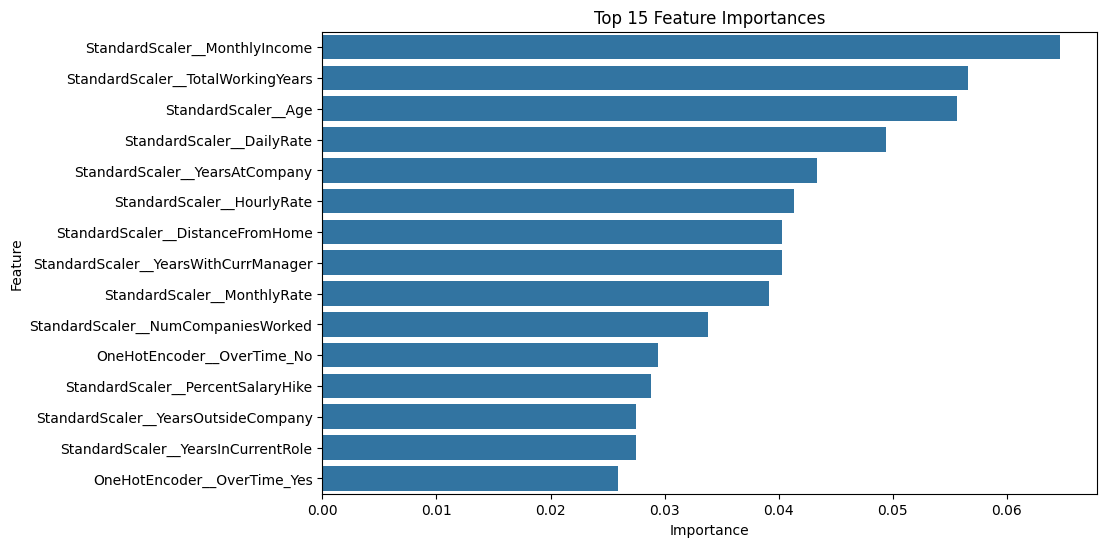

In [54]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")
plt.show()

In [56]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_test_pred = model.predict(X_test)

    # Probability for ROC-AUC
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_test_proba)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Gradient Boosting,0.853741,0.625000,0.212766,0.317460,0.812301
0,Logistic Regression,0.751701,0.348837,0.638298,0.451128,0.800930
2,Random Forest,0.846939,0.625000,0.106383,0.181818,0.778577
4,KNN,0.850340,0.666667,0.127660,0.214286,0.653588
1,Decision Tree,0.751701,0.240000,0.255319,0.247423,0.550736


In [57]:
def evaluate_model(true, predicted):

    accuracy = accuracy_score(true, predicted)
    precision = precision_score(true, predicted)
    recall = recall_score(true, predicted)
    f1 = f1_score(true, predicted)

    return accuracy, precision, recall, f1

In [58]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}


for name , model in models.items():
    # Train model
    model.fit(X_train,y_train)

    #Predictions

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate training test

    train_accuracy, train_precision , train_recall, train_f1 = evaluate_model(
        y_train,
        y_train_pred
    )


  
    # Evaluate test set
    test_accuracy,test_precision,test_recall,test_f1 = evaluate_model(
        y_test,
        y_test_pred
    )

    print(name)

    print("Training Performance")
    print("- Accuracy :", train_accuracy)
    print("- Precision:", train_precision)
    print("- Recall   :", train_recall)
    print("- F1 Score :", train_f1)

    print("\nTest Performance")
    print("- Accuracy :", test_accuracy)
    print("- Precision:", test_precision)
    print("- Recall   :", test_recall)
    print("- F1 Score :", test_f1)

    print("=" * 50)

    

Logistic Regression
Training Performance
- Accuracy : 0.9047619047619048
- Precision: 0.8421052631578947
- Recall   : 0.5052631578947369
- F1 Score : 0.631578947368421

Test Performance
- Accuracy : 0.8605442176870748
- Precision: 0.6153846153846154
- Recall   : 0.3404255319148936
- F1 Score : 0.4383561643835616
Decision Tree
Training Performance
- Accuracy : 1.0
- Precision: 1.0
- Recall   : 1.0
- F1 Score : 1.0

Test Performance
- Accuracy : 0.7755102040816326
- Precision: 0.30612244897959184
- Recall   : 0.3191489361702128
- F1 Score : 0.3125
Random Forest
Training Performance
- Accuracy : 1.0
- Precision: 1.0
- Recall   : 1.0
- F1 Score : 1.0

Test Performance
- Accuracy : 0.8469387755102041
- Precision: 0.6
- Recall   : 0.1276595744680851
- F1 Score : 0.21052631578947367
Gradient Boosting
Training Performance
- Accuracy : 0.95578231292517
- Precision: 1.0
- Recall   : 0.7263157894736842
- F1 Score : 0.8414634146341463

Test Performance
- Accuracy : 0.8537414965986394
- Precision: 

In [59]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [60]:
print("Train:", X_train_sub.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

Train: (940, 53)
Validation: (236, 53)
Test: (294, 53)

Validation target distribution:
Attrition
0    0.838983
1    0.161017
Name: proportion, dtype: float64


In [61]:
logistic_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

logistic_balanced.fit(X_train_sub, y_train_sub)

y_val_prob = logistic_balanced.predict_proba(X_val)[:, 1]

In [62]:
print(y_val_prob[:10])

[0.04328008 0.05346481 0.25697388 0.03272921 0.03575215 0.02809811
 0.08166053 0.181958   0.57403905 0.16038443]


In [63]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

for threshold in thresholds:

    y_val_pred = (y_val_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, zero_division=0)
    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)

    print("Threshold:", threshold)
    print("Accuracy :", round(accuracy, 3))
    print("Precision:", round(precision, 3))
    print("Recall   :", round(recall, 3))
    print("F1 Score :", round(f1, 3))
    print("-" * 40)

Threshold: 0.3
Accuracy : 0.631
Precision: 0.275
Recall   : 0.789
F1 Score : 0.408
----------------------------------------
Threshold: 0.35
Accuracy : 0.653
Precision: 0.288
Recall   : 0.789
F1 Score : 0.423
----------------------------------------
Threshold: 0.4
Accuracy : 0.669
Precision: 0.3
Recall   : 0.789
F1 Score : 0.435
----------------------------------------
Threshold: 0.45
Accuracy : 0.712
Precision: 0.33
Recall   : 0.763
F1 Score : 0.46
----------------------------------------
Threshold: 0.5
Accuracy : 0.742
Precision: 0.358
Recall   : 0.763
F1 Score : 0.487
----------------------------------------
Threshold: 0.55
Accuracy : 0.771
Precision: 0.392
Recall   : 0.763
F1 Score : 0.518
----------------------------------------
Threshold: 0.6
Accuracy : 0.792
Precision: 0.415
Recall   : 0.711
F1 Score : 0.524
----------------------------------------


In [64]:
thresholds = [0.55, 0.60, 0.65, 0.70]
for threshold in thresholds:

    y_val_pred = (y_val_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, zero_division=0)
    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)

    print("Threshold:", threshold)
    print("Accuracy :", round(accuracy, 3))
    print("Precision:", round(precision, 3))
    print("Recall   :", round(recall, 3))
    print("F1 Score :", round(f1, 3))
    print("-" * 40)

Threshold: 0.55
Accuracy : 0.771
Precision: 0.392
Recall   : 0.763
F1 Score : 0.518
----------------------------------------
Threshold: 0.6
Accuracy : 0.792
Precision: 0.415
Recall   : 0.711
F1 Score : 0.524
----------------------------------------
Threshold: 0.65
Accuracy : 0.831
Precision: 0.481
Recall   : 0.658
F1 Score : 0.556
----------------------------------------
Threshold: 0.7
Accuracy : 0.869
Precision: 0.581
Recall   : 0.658
F1 Score : 0.617
----------------------------------------


In [65]:
final_threshold = 0.70

y_test_prob = logistic_balanced.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= final_threshold).astype(int)

print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Accuracy : 0.8299319727891157
Precision: 0.46808510638297873
Recall   : 0.46808510638297873
F1 Score : 0.46808510638297873

Confusion Matrix:
[[222  25]
 [ 25  22]]


In [66]:
y_test_prob = logistic_balanced.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_test_prob)

print("Logistic Regression ROC-AUC:", roc_auc)

Logistic Regression ROC-AUC: 0.7826686191747781


In [67]:
gradient_boosting = GradientBoostingClassifier(random_state=42)

gradient_boosting.fit(X_train, y_train)

y_gb_prob = gradient_boosting.predict_proba(X_test)[:, 1]

gb_auc = roc_auc_score(y_test, y_gb_prob)

print("Gradient Boosting ROC-AUC:", gb_auc)

Gradient Boosting ROC-AUC: 0.8123008011025927


In [68]:
y_gb_pred = (y_gb_prob >= 0.50).astype(int)

print("Accuracy :", accuracy_score(y_test, y_gb_pred))
print("Precision:", precision_score(y_test, y_gb_pred))
print("Recall   :", recall_score(y_test, y_gb_pred))
print("F1 Score :", f1_score(y_test, y_gb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_gb_pred))

Accuracy : 0.8537414965986394
Precision: 0.625
Recall   : 0.2127659574468085
F1 Score : 0.31746031746031744

Confusion Matrix:
[[241   6]
 [ 37  10]]


In [69]:
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45]

for threshold in thresholds:
    y_pred = (y_gb_prob >= threshold).astype(int)

    print(f"Threshold: {threshold}")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
    print("Precision:", round(precision_score(y_test, y_pred), 3))
    print("Recall   :", round(recall_score(y_test, y_pred), 3))
    print("F1 Score :", round(f1_score(y_test, y_pred), 3))
    print("-" * 40)

Threshold: 0.2
Accuracy : 0.81
Precision: 0.433
Recall   : 0.617
F1 Score : 0.509
----------------------------------------
Threshold: 0.25
Accuracy : 0.806
Precision: 0.414
Recall   : 0.511
F1 Score : 0.457
----------------------------------------
Threshold: 0.3
Accuracy : 0.823
Precision: 0.447
Recall   : 0.447
F1 Score : 0.447
----------------------------------------
Threshold: 0.35
Accuracy : 0.84
Precision: 0.5
Recall   : 0.362
F1 Score : 0.42
----------------------------------------
Threshold: 0.4
Accuracy : 0.84
Precision: 0.5
Recall   : 0.277
F1 Score : 0.356
----------------------------------------
Threshold: 0.45
Accuracy : 0.85
Precision: 0.588
Recall   : 0.213
F1 Score : 0.312
----------------------------------------
